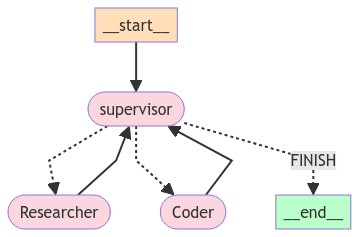

In [ ]:
from langchain.agents import AgentExecutor, create_openai_tools_agent
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers.openai_functions import JsonOutputFunctionsParser

import operator
from typing import Annotated, Any, Dict, List, Optional, Sequence, TypedDict
import functools
import os
import yaml

from pprint import pprint

from IPython.display import Image

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import StateGraph, END

from typing import Annotated, List, Tuple, Union

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.tools import PythonREPLTool

MODEL = "gpt-3.5-turbo"
# MODEL = "gpt-4o"

# * API KEYS

os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

os.environ["TAVILY_API_KEY"] = yaml.safe_load(open("../credentials.yml"))['tavily']

# * Create tools

tavily_tool = TavilySearchResults(max_results=5)

# This executes code locally, which can be unsafe
python_repl_tool = PythonREPLTool()

# * Helper Utilities

def create_agent(llm: ChatOpenAI, tools: list, system_prompt: str):
    # Each worker node will be given a name and some tools.
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                system_prompt,
            ),
            MessagesPlaceholder(variable_name="messages"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ]
    )
    agent = create_openai_tools_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools)
    return executor

def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["output"], name=name)]}


# * Create Agent Supervisor

members = ["Researcher", "Coder"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " following workers:  {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed
options = ["FINISH"] + members

# Using openai function calling can make output parsing easier for us
function_def = {
    "name": "route",
    "description": "Select the next role.",
    "parameters": {
        "title": "routeSchema",
        "type": "object",
        "properties": {
            "next": {
                "title": "Next",
                "anyOf": [
                    {"enum": options},
                ],
            }
        },
        "required": ["next"],
    },
}

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            "Given the conversation above, who should act next?"
            " Or should we FINISH? Select one of: {options}",
        ),
    ]
).partial(options=str(options), members=", ".join(members))

llm = ChatOpenAI(model=MODEL)

supervisor_chain = (
    prompt
    | llm.bind_functions(functions=[function_def], function_call="route")
    | JsonOutputFunctionsParser()
)

# * Research and Code Agents

research_agent = create_agent(llm, [tavily_tool], "You are a web researcher.")

research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION. PROCEED WITH CAUTION
code_agent = create_agent(
    llm,
    [python_repl_tool],
    "You may generate safe python code to analyze data and generate charts using matplotlib.",
)

code_node = functools.partial(agent_node, agent=code_agent, name="Coder")

# * Construct Graph

# The agent state is the input to each node in the graph
class AgentState(TypedDict):
    # The annotation tells the graph that new messages will always
    # be added to the current states
    messages: Annotated[Sequence[BaseMessage], operator.add]
    # The 'next' field indicates where to route to next
    next: str

workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node)
workflow.add_node("Coder", code_node)
workflow.add_node("supervisor", supervisor_chain)

for member in members:
    # We want our workers to ALWAYS "report back" to the supervisor when done
    workflow.add_edge(member, "supervisor")
    
# The supervisor populates the "next" field in the graph state
# which routes to a node or finishes
conditional_map = {k: k for k in members}
conditional_map["FINISH"] = END

workflow.add_conditional_edges("supervisor", lambda x: x["next"], conditional_map)

# Finally, add entrypoint
workflow.set_entry_point("supervisor")

graph = workflow.compile()

Image(graph.get_graph().draw_mermaid_png())

In [ ]:
result_3 = graph.invoke(
    input = {"messages": [HumanMessage(content="Find the historical daily price of SPY for the last 3 years. Plot in a line chart of daily SPY value over time.")]},
    config = {"recursion_limit": 40},
)

result_3

{'messages': [HumanMessage(content='Find the historical daily price of SPY for the last 3 years. Plot in a line chart of daily SPY value over time.'),
  HumanMessage(content='I found some sources where you can access the historical daily price data of SPY for the last 3 years:\n\n1. [Wall Street Journal - SPDR S&P 500 ETF Trust (SPY) Historical Prices](https://www.wsj.com/market-data/quotes/etf/SPY/historical-prices)\n2. [Macrotrends - SPDR S&P 500 ETF Historical Stock Price Chart](https://www.macrotrends.net/stocks/charts/SPY/spdr-s-p-500-etf/stock-price-history)\n3. [Barchart - S&P 500 SPDR (SPY) Price History](https://www.barchart.com/etfs-funds/quotes/SPY/price-history/historical)\n4. [Investing.com - SPDR S&P 500 Historical Data](https://www.investing.com/etfs/spdr-s-p-500-historical-data)\n5. [Yahoo Finance - SPDR S&P 500 ETF Trust Historical Prices](https://finance.yahoo.com/quote/SPY/history)\n\nYou can visit these websites to retrieve the historical daily price data of SPY for

In [ ]:
result_3 = graph.invoke(
    input = {"messages": [HumanMessage(content="Find the historical daily price of SPY for the last 3 years. Plot in a line chart the daily SPY value over time using python.")]},
    config = {"recursion_limit": 40},
)

result_3

{'messages': [HumanMessage(content='Find the historical daily price of SPY for the last 3 years. Plot in a line chart the daily SPY value over time using python.'),
  HumanMessage(content='I found several sources where you can access historical daily price data for SPY for the last 3 years:\n\n1. [Investing.com - SPDR S&P 500 ETF Historical Data](https://www.investing.com/etfs/spdr-s-p-500-historical-data)\n2. [Barchart - S&P 500 SPDR (SPY) Price History](https://www.barchart.com/etfs-funds/quotes/SPY/price-history/historical)\n3. [Nasdaq - SPDR S&P 500 ETF Trust Units (SPY) Historical ETF Quotes](https://www.nasdaq.com/market-activity/etf/spy/historical)\n4. [Yahoo Finance - SPDR S&P 500 ETF Trust Historical Prices](https://finance.yahoo.com/quote/SPY/history)\n\nYou can visit these websites to access the historical daily price data for SPY. After obtaining the data, you can plot the daily SPY value over time using Python. Let me know if you need further assistance with plotting the d

Python REPL can execute arbitrary code. Use with caution.


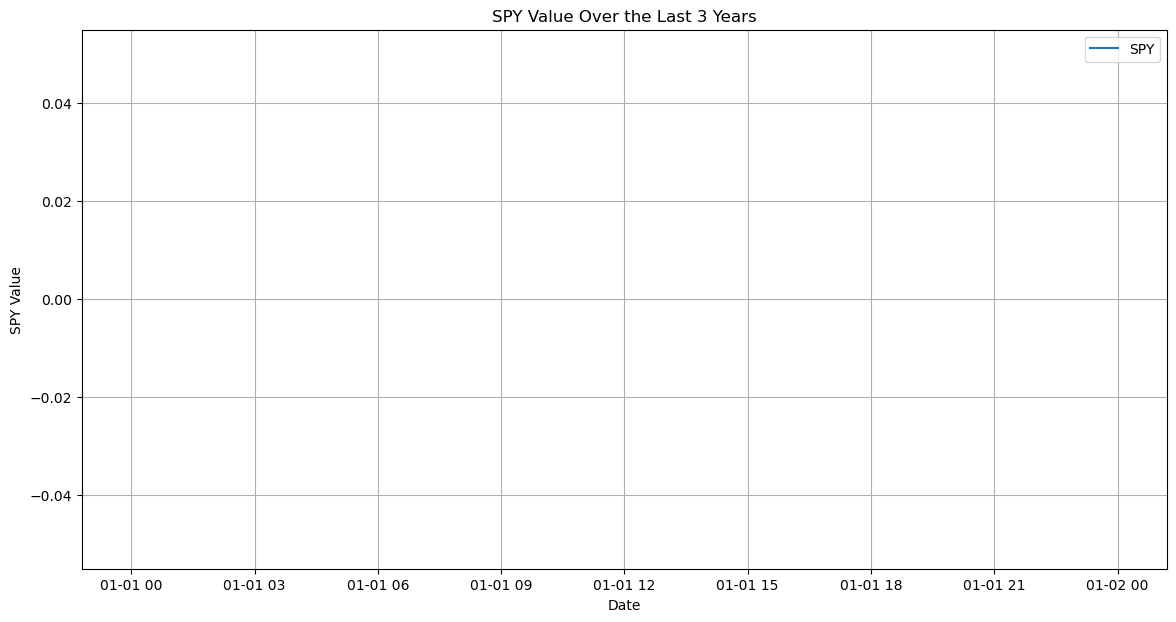

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.'),
  HumanMessage(content="I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.\n\nTo create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.\nI will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.", name='Researcher'),
  HumanMessage(content='I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:\n\n1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote/SPY/history)\n2. [Nasda

In [ ]:
result_3 = graph.invoke(
    input = {"messages": [HumanMessage(content="Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.")]},
    config = {"recursion_limit": 40},
)

result_3

In [ ]:
pprint(result_3)

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.'),
              HumanMessage(content="I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.\n\nTo create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.\nI will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.", name='Researcher'),
              HumanMessage(content='I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:\n\n1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote

In [ ]:
pprint(result_3, width=40)

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.'),
              HumanMessage(content="I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.\n\nTo create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.\nI will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.", name='Researcher'),
              HumanMessage(content='I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:\n\n1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote

In [ ]:
pprint(dict(result_3), width=40)

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.'),
              HumanMessage(content="I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.\n\nTo create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.\nI will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.", name='Researcher'),
              HumanMessage(content='I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:\n\n1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote

In [ ]:
pprint(dict(result_3), width=40, compact=True)

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.'),
              HumanMessage(content="I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.\n\nTo create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.\nI will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.", name='Researcher'),
              HumanMessage(content='I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:\n\n1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote

In [ ]:
result_3

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.'),
  HumanMessage(content="I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.\n\nTo create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.\nI will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.", name='Researcher'),
  HumanMessage(content='I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:\n\n1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote/SPY/history)\n2. [Nasda

In [ ]:
for message in result_3['messages']:
    print(f"Content: {message.content}")
    if hasattr(message, 'name'):
        print(f"Name: {message.name}")
    print()

Content: Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.
Name: None

Content: I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.

To create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.
I will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.
Name: Researcher

Content: I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:

1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote/SPY/history)
2. [Nasdaq - SPY Historical ETF Quotes](https://www.nasdaq.com/mark

In [ ]:
result_3["messages"]

[HumanMessage(content='Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.'),
 HumanMessage(content="I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.\n\nTo create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.\nI will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.", name='Researcher'),
 HumanMessage(content='I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:\n\n1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote/SPY/history)\n2. [Nasdaq - SPY Histori

In [ ]:
result_3["messages"][-1]

HumanMessage(content='The data extraction and plotting for the SPY value over the last 3 years have been completed successfully. You can view the line chart showing the SPY value over time.\n\nIf you have any specific data that you would like to analyze or any other tasks, feel free to let me know!', name='Coder')

In [ ]:
result_3["messages"][-1].name

'Coder'

In [ ]:
for message in result_3['messages']:
    print(f"Content: {message.content}")
    if message.name:
        print(f"Name: {message.name}")
    print()

Content: Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.

Content: I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.

To create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.
I will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.
Name: Researcher

Content: I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:

1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote/SPY/history)
2. [Nasdaq - SPY Historical ETF Quotes](https://www.nasdaq.com/market-activity

In [ ]:
for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    print(f"Content: {message.content}")
    print("---")
    print()

Content: Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.
---

Name: Researcher
Content: I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.

To create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.
I will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.
---

Name: Researcher
Content: I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:

1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote/SPY/history)
2. [Nasdaq - SPY Historical ETF Quotes](https://www.n

In [ ]:
for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    pprint(f"Content: {message.content}")
    print("---")
    print()

('Content: Find the historical prices of SPY for the last 3 years. Plot in a '
 'line chart the SPY value over time from the historical prices using python.')
---

Name: Researcher
('Content: I have found multiple sources for historical prices of SPY. You can '
 'access the historical price data for SPY on Yahoo Finance, Nasdaq, and other '
 'financial platforms.\n'
 '\n'
 'To create a line chart of the SPY value over the last 3 years using Python, '
 'I will now proceed to extract the necessary historical price data for SPY.\n'
 'I will now extract the historical price data for SPY from the available '
 'sources and proceed with plotting the SPY value over the last 3 years using '
 "Python. Let's begin by retrieving the data.")
---

Name: Researcher
('Content: I have found historical price data for SPY on Yahoo Finance and '
 'Nasdaq. Here are the links where you can access the historical prices:\n'
 '\n'
 '1. [Yahoo Finance - SPY Historical '
 'Prices](https://finance.yahoo.com/quote

In [ ]:
for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    print(f"Content: {message.content}")
    print("---")
    print()

Content: Find the historical prices of SPY for the last 3 years. Plot in a line chart the SPY value over time from the historical prices using python.
---

Name: Researcher
Content: I have found multiple sources for historical prices of SPY. You can access the historical price data for SPY on Yahoo Finance, Nasdaq, and other financial platforms.

To create a line chart of the SPY value over the last 3 years using Python, I will now proceed to extract the necessary historical price data for SPY.
I will now extract the historical price data for SPY from the available sources and proceed with plotting the SPY value over the last 3 years using Python. Let's begin by retrieving the data.
---

Name: Researcher
Content: I have found historical price data for SPY on Yahoo Finance and Nasdaq. Here are the links where you can access the historical prices:

1. [Yahoo Finance - SPY Historical Prices](https://finance.yahoo.com/quote/SPY/history)
2. [Nasdaq - SPY Historical ETF Quotes](https://www.n

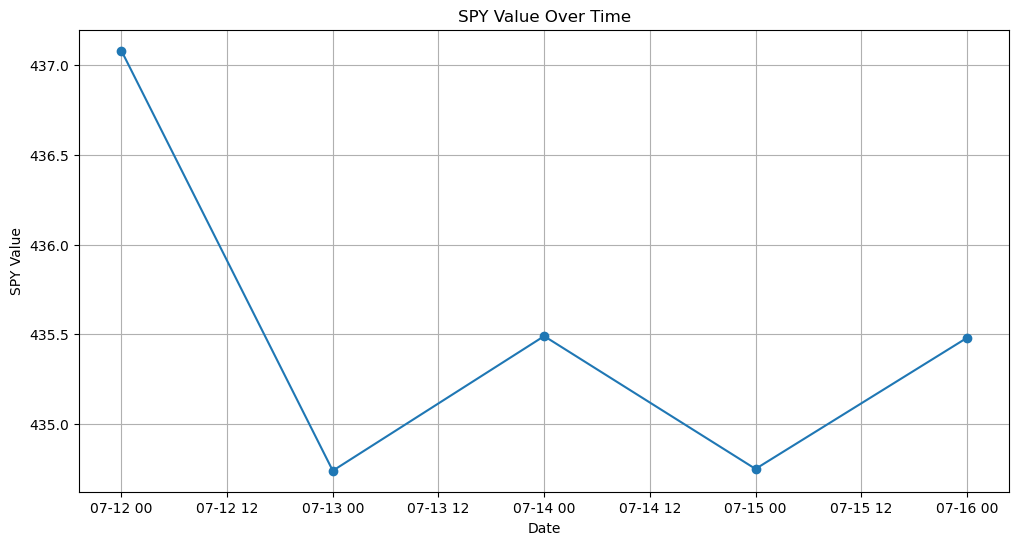

In [ ]:
result_3 = graph.invoke(
    input = {"messages": [HumanMessage(content="Find the historical prices of SPY for the last 5 years. Plot in a line chart the SPY value over time from the historical prices using python.")]},
    config = {"recursion_limit": 40},
)

In [ ]:
for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    print(f"Content: {message.content}")
    print("---")
    print()

Content: Find the historical prices of SPY for the last 5 years. Plot in a line chart the SPY value over time from the historical prices using python.
---

Name: Researcher
Content: I found sources where you can retrieve the historical prices of SPY for the last 5 years. You can access this information from the following websites:

1. [Macrotrends](https://www.macrotrends.net/stocks/charts/SPY/spdr-s-p-500-etf/stock-price-history)
2. [Investing.com](https://www.investing.com/etfs/spdr-s-p-500-historical-data)
3. [Yahoo Finance](https://finance.yahoo.com/quote/SPY/history)
4. [Wall Street Journal](https://www.wsj.com/market-data/quotes/etf/SPY/historical-prices)
5. [Yahoo Finance Canada](https://ca.finance.yahoo.com/quote/SPY/history/)

You can visit these websites to access the historical prices data. Once you have the data, you can proceed to plot the SPY value over time in a line chart using Python. If you need further assistance with plotting the data, feel free to let me know!
---


In [ ]:
result_3 = graph.invoke(
    input = {"messages": [HumanMessage(content="Find the historical prices of SPY for the last 5 years from Yahoo Finance. Plot in a line chart the SPY value over time from the historical prices using python.")]},
    config = {"recursion_limit": 40},
)

result_3["messages"][-1].name

pprint(dict(result_3), width=40, compact=True)

for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    print(f"Content: {message.content}")
    print("---")
    print()

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 5 years from Yahoo Finance. Plot in a line chart the SPY value over time from the historical prices using python.'),
              HumanMessage(content='I found the historical prices for SPY on Yahoo Finance. You can view the historical prices by visiting the following link: [SPY Historical Prices on Yahoo Finance](https://finance.yahoo.com/quote/SPY/history).\n\nNow, I will proceed to plot the SPY value over time for the last 5 years using Python.\nTo plot the historical prices of SPY for the last 5 years, I will use Python with the help of the `pandas` and `matplotlib` libraries. \n\nHere is the Python code to retrieve the historical prices from Yahoo Finance and plot them in a line chart:\n\n```python\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport yfinance as yf\n\n# Define the ticker symbol for SPY\nticker_symbol = \'SPY\'\n\n# Download historical data from Yahoo Finance for the last 5

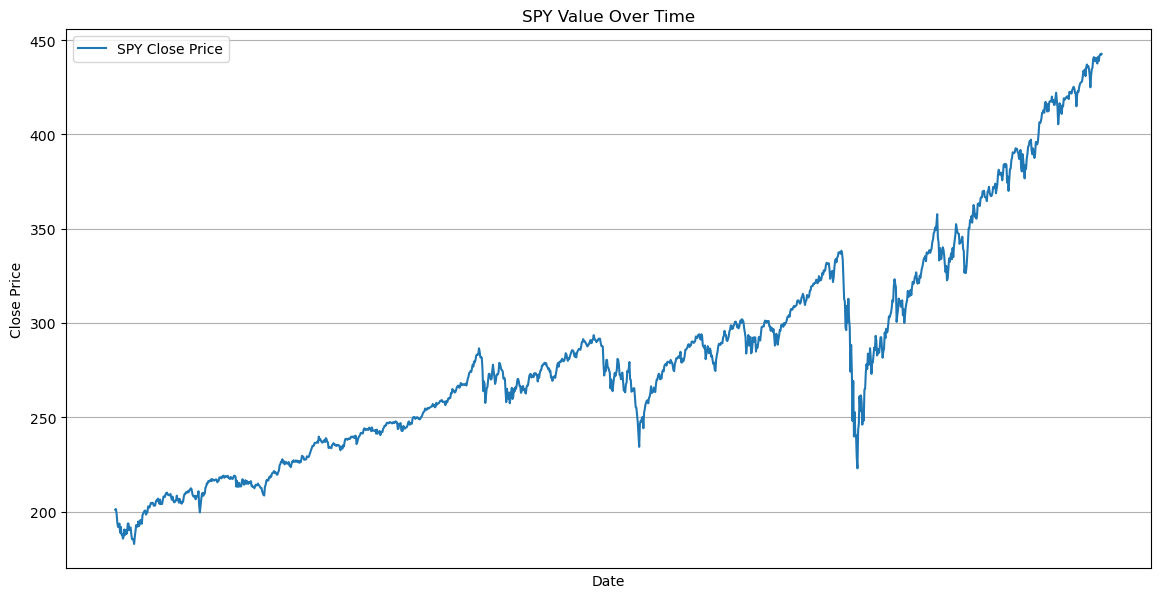

{'messages': [HumanMessage(content='Find the historical prices of SPY for the last 5 years from Yahoo Finance. Plot a line chart of the SPY value over time from the historical prices using python.'),
              HumanMessage(content="I found the historical prices of SPY on Yahoo Finance. You can view the historical prices for SPY [here](https://finance.yahoo.com/quote/SPY/history).\n\nTo plot a line chart of the SPY value over time from the historical prices using Python, we will need to download the historical data from the provided link and then create a line chart using a Python library like Matplotlib.\n\nLet's proceed with downloading the historical prices for SPY.\nI will now proceed with downloading the historical prices for SPY from Yahoo Finance and then plot a line chart of the SPY value over time using Python.", name='Researcher'),
              HumanMessage(content='The line chart displaying the SPY value over time has been successfully plotted. You can see the visualizat

In [ ]:
result_3 = graph.invoke(
    input = {"messages": [HumanMessage(content="Find the historical prices of SPY for the last 5 years from Yahoo Finance. Plot a line chart of the SPY value over time from the historical prices using python.")]},
    config = {"recursion_limit": 40},
)

result_3["messages"][-1].name

pprint(dict(result_3), width=40, compact=True)

for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    print(f"Content: {message.content}")
    print("---")
    print()

In [ ]:
for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    print(f"Content: {message.content}")
    print("---")
    print()

Content: Find the historical prices of SPY for the last 5 years from Yahoo Finance. Plot a line chart of the SPY value over time from the historical prices using python.
---

Name: Researcher
Content: I found the historical prices of SPY on Yahoo Finance. You can view the historical prices for SPY [here](https://finance.yahoo.com/quote/SPY/history).

To plot a line chart of the SPY value over time from the historical prices using Python, we will need to download the historical data from the provided link and then create a line chart using a Python library like Matplotlib.

Let's proceed with downloading the historical prices for SPY.
I will now proceed with downloading the historical prices for SPY from Yahoo Finance and then plot a line chart of the SPY value over time using Python.
---

Name: Coder
Content: The line chart displaying the SPY value over time has been successfully plotted. You can see the visualization above.

If you have any specific analysis or further questions, feel

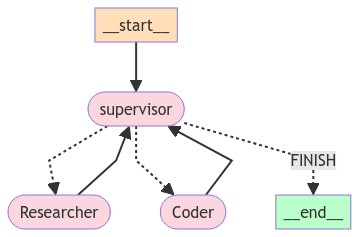

In [ ]:
Image(graph.get_graph().draw_mermaid_png())

In [ ]:
for message in result_3['messages']:
    if message.name:
        print(f"Name: {message.name}")
    print(f"Content: {message.content}")
    print("---")
    print()

Content: Find the historical prices of SPY for the last 5 years from Yahoo Finance. Plot a line chart of the SPY value over time from the historical prices using python.
---

Name: Researcher
Content: I found the historical prices of SPY on Yahoo Finance. You can view the historical prices for SPY [here](https://finance.yahoo.com/quote/SPY/history).

To plot a line chart of the SPY value over time from the historical prices using Python, we will need to download the historical data from the provided link and then create a line chart using a Python library like Matplotlib.

Let's proceed with downloading the historical prices for SPY.
I will now proceed with downloading the historical prices for SPY from Yahoo Finance and then plot a line chart of the SPY value over time using Python.
---

Name: Coder
Content: The line chart displaying the SPY value over time has been successfully plotted. You can see the visualization above.

If you have any specific analysis or further questions, feel